In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[0]   # move up from notebooks/
sys.path.insert(0, str(PROJECT_ROOT))
from data import ESMCSingleDS
import torch
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

In [2]:
data_name = 'IEDB_Jespersen'
model_name = 'esmc_300m'
base_data_dir = Path.cwd().parents[0]  / 'data'/ 'data_files'
dataset = ESMCSingleDS(data_name, model_name, save_dir=base_data_dir, max_len=3000)
full_data = np.load(dataset.file_path.parent / 'embeddings.npy')
full_labels = np.load(dataset.file_path.parent / 'labels.npy')
full_pca = PCA(n_components=15)
full_pca.fit(full_data)

Dropped 120 sequences over len 3000


PCA(n_components=15)

In [3]:

def plot_pcas(idx, pc1=0, pc2=1, pc3=2):
    x, y = dataset[idx]
    single_pca = PCA(n_components=15)
    single_transform = single_pca.fit_transform(x)
    batch_transform = full_pca.transform(x)
    ln_pca = PCA(n_components=15)
    ln_data = (x - x.mean(-1, keepdims=True)) - x.std(-1, keepdims=True)
    ln_transform = ln_pca.fit_transform(ln_data)

    fig, axs = plt.subplots(2, 3, figsize=(10, 5))
    axs[0, 0].set_title('Single Transform')
    axs[0, 0].scatter(single_transform[:, pc1], single_transform[:, pc2], c=y.numpy(), cmap=plt.get_cmap('jet'))
    axs[1, 0].scatter(single_transform[:, pc2], single_transform[:, pc3], c=y.numpy(), cmap=plt.get_cmap('jet'))

    axs[0, 1].set_title('Batch Transform')
    axs[0, 1].scatter(batch_transform[:, pc1], batch_transform[:, pc2], c=y.numpy(), cmap=plt.get_cmap('jet'))
    axs[1, 1].scatter(batch_transform[:, pc2], batch_transform[:, pc3], c=y.numpy(), cmap=plt.get_cmap('jet'))

    axs[0, 2].set_title('Layer Norm Transform')
    axs[0, 2].scatter(ln_transform[:, pc1], ln_transform[:, pc2], c=y.numpy(), cmap=plt.get_cmap('jet'))
    axs[1, 2].scatter(ln_transform[:, pc2], ln_transform[:, pc3], c=y.numpy(), cmap=plt.get_cmap('jet'))



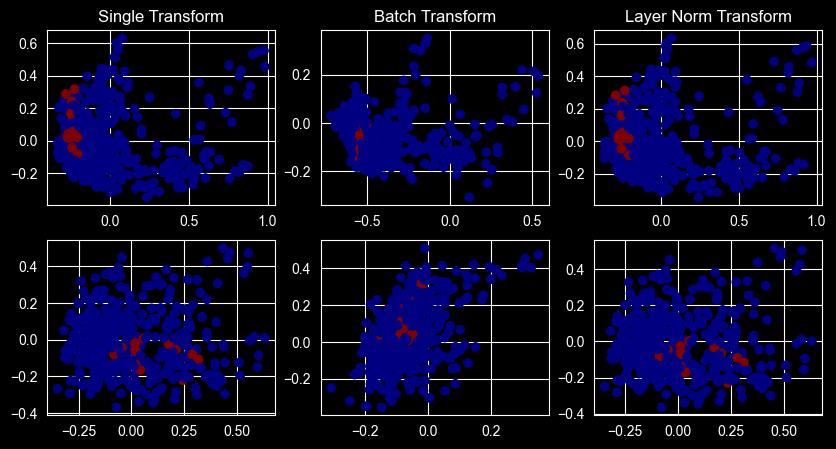

In [4]:
plot_pcas(1)

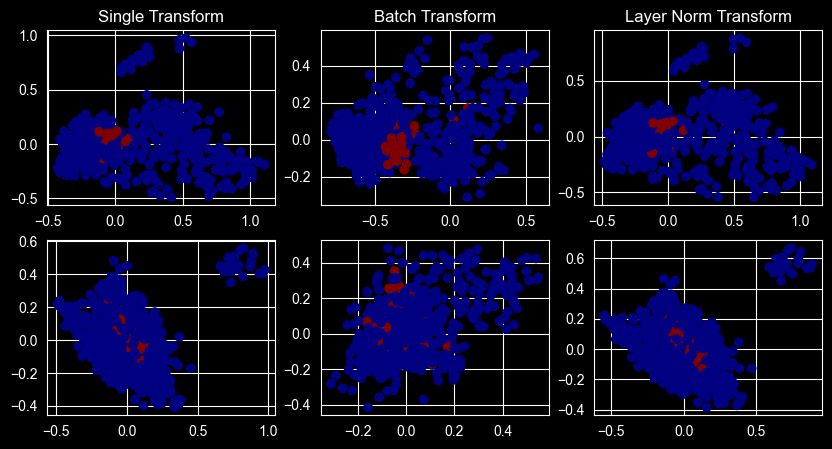

In [5]:
plot_pcas(2)

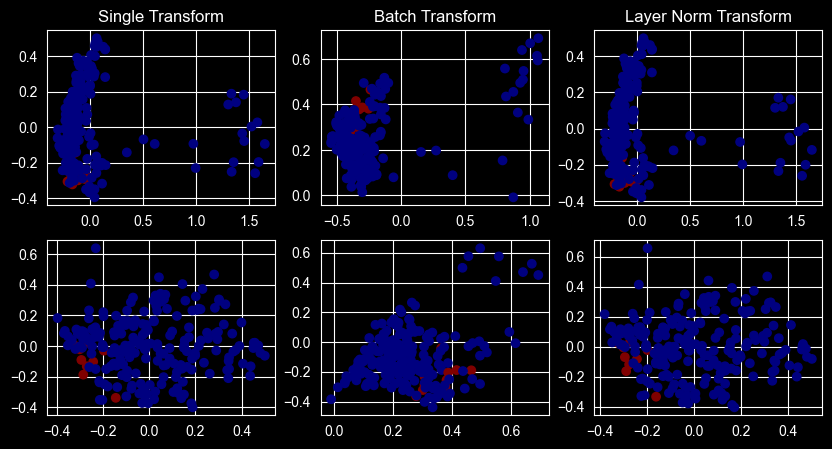

In [6]:
plot_pcas(3)

In [7]:
kmeans = KMeans(n_clusters=20, n_init=10)
transformed = full_pca.transform(full_data)
clusters = kmeans.fit_predict(transformed)


In [8]:
for c in np.unique(clusters):
    mask = clusters == c
    frac = full_labels[mask].mean()
    print(c, frac)

0 0.03370061
1 0.0166903
2 0.028009063
3 0.031242458
4 0.032080423
5 0.023301855
6 0.027588584
7 0.0337962
8 0.020232888
9 0.028510299
10 0.009343061
11 0.02305237
12 0.0318937
13 0.022011077
14 0.028121242
15 0.015683265
16 0.024562115
17 0.03372355
18 0.009895849
19 0.023921112
